In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !pip install timm opencv-python pandas
#

In [ ]:
#

# Dataset03

Label mapping: {'aedes': 0, 'anopheles': 1, 'culex': 2}
Train size: 1200 Test size: 1200
Train class counts: {'anopheles': 400, 'culex': 400, 'aedes': 400}
Test class counts: {'anopheles': 400, 'culex': 400, 'aedes': 400}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


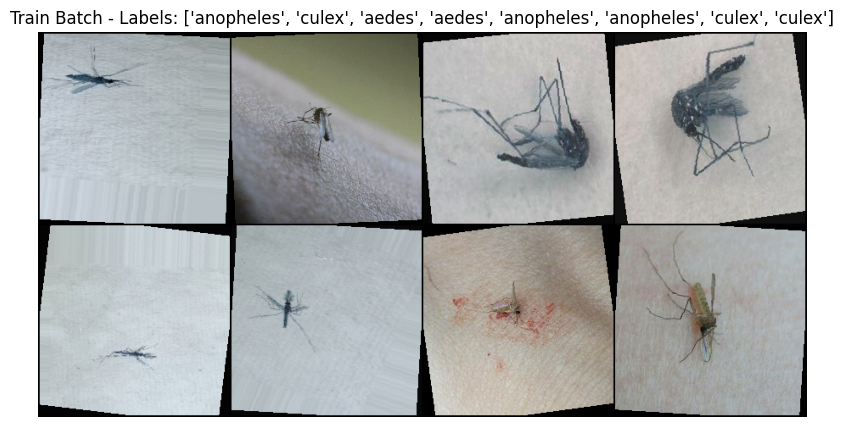

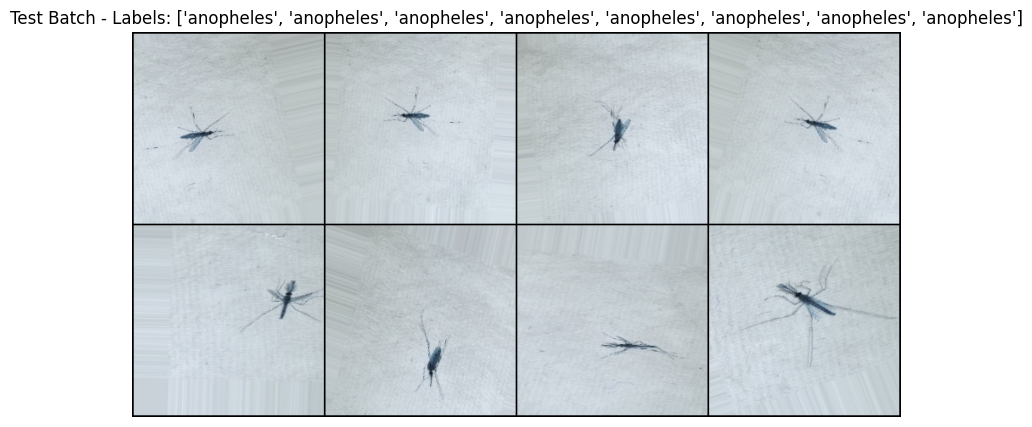

In [ ]:
# ============================
# Complete Updated DataLoader
# ============================

import pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
from torchvision import transforms
import matplotlib.pyplot as plt
import torchvision
import torch
from torch.utils.data._utils.collate import default_collate

# -------------------------
# Config
# -------------------------
DRIVE_ROOT = "/content/drive/MyDrive/Dataset_3"
IMG_SIZE = 224
PATCH_SIZE = 16
BATCH_SIZE = 16
NUM_WORKERS = 2

# -------------------------
# Build shared label map
# -------------------------
def build_label_map(csv_paths):
    labels = []
    for p in csv_paths:
        df = pd.read_csv(p)
        labels.extend(df['label'].unique())
    labels = sorted(list(set(labels)))
    return {lab: i for i, lab in enumerate(labels)}

train_csv = os.path.join(DRIVE_ROOT, "d3_train_fixed.csv")
test_csv  = os.path.join(DRIVE_ROOT, "d3_test_fixed.csv")

label2idx = build_label_map([train_csv, test_csv])
idx2label = {v: k for k, v in label2idx.items()}

print("Label mapping:", label2idx)

# -------------------------
# Transforms
# -------------------------
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

# -------------------------
# Dataset Class
# -------------------------
class MosquitoDataset(Dataset):
    def __init__(self, csv_file, label2idx, transform=None, return_pil=True,
                 root_replace_from="../Dataset_3", root_replace_to=DRIVE_ROOT):
        self.data = pd.read_csv(csv_file).copy()
        self.transform = transform
        self.return_pil = return_pil
        self.label2idx = label2idx

        if 'filepath' not in self.data.columns:
            raise ValueError("CSV must contain a 'filepath' column")

        # Fix filepaths robustly
        self.data['filepath'] = self.data['filepath'].astype(str).apply(
            lambda p: p.replace(root_replace_from, root_replace_to)
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['filepath']
        label_str = self.data.iloc[idx]['label']
        label = self.label2idx[label_str]

        image_pil = Image.open(img_path).convert('RGB')
        image_tensor = self.transform(image_pil)

        if self.return_pil:
            return image_tensor, label, image_pil, img_path
        else:
            return image_tensor, label

# -------------------------
# Custom collate function
# (handles PIL images + paths)
# -------------------------
def custom_collate(batch):
    """
    batch = [(tensor, label, pil_img, path), ...]
    """
    tensors = [item[0] for item in batch]
    labels  = [item[1] for item in batch]
    pils    = [item[2] for item in batch]
    paths   = [item[3] for item in batch]

    batch_tensors = default_collate(tensors)
    batch_labels  = default_collate(labels)

    return batch_tensors, batch_labels, pils, paths

# -------------------------
# Create Datasets & Loaders
# -------------------------
train_dataset = MosquitoDataset(train_csv, label2idx, transform=train_transform, return_pil=True)
test_dataset  = MosquitoDataset(test_csv, label2idx, transform=test_transform, return_pil=True)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=custom_collate
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=custom_collate
)

# -------------------------
# Show batch function
# -------------------------
def show_batch(loader, title="Batch"):
    images, labels, pils, paths = next(iter(loader))
    images = images[:8]
    labels = labels[:8]

    # unnormalize for display
    mean = torch.tensor(NORMALIZE_MEAN).view(3,1,1)
    std  = torch.tensor(NORMALIZE_STD).view(3,1,1)
    images_unnorm = images * std + mean

    # REMOVE clamp=True to avoid error
    grid_img = torchvision.utils.make_grid(images_unnorm, nrow=4)

    plt.figure(figsize=(10, 5))
    plt.imshow(grid_img.permute(1, 2, 0).cpu().numpy())
    plt.title(f"{title} - Labels: {[idx2label[int(l)] for l in labels]}")
    plt.axis('off')
    plt.show()

# -------------------------
# Preview
# -------------------------
print("Train size:", len(train_dataset), "Test size:", len(test_dataset))
print("Train class counts:", pd.read_csv(train_csv)['label'].value_counts().to_dict())
print("Test class counts:", pd.read_csv(test_csv)['label'].value_counts().to_dict())

show_batch(train_loader, title="Train Batch")
show_batch(test_loader, title="Test Batch")


Using device: cuda
Model parameters (M): 4.997578
Epoch 1 Step 5 avg loss 2.0427
Epoch 1 time: 31.2s


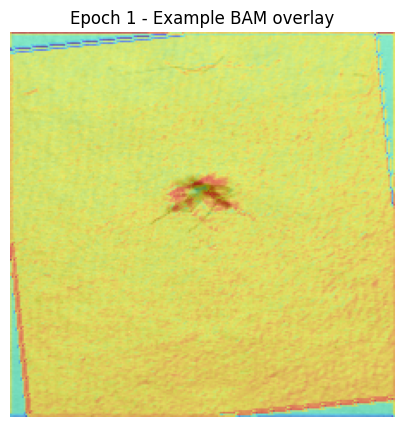

Epoch 2 Step 5 avg loss 1.1416
Epoch 2 time: 29.4s


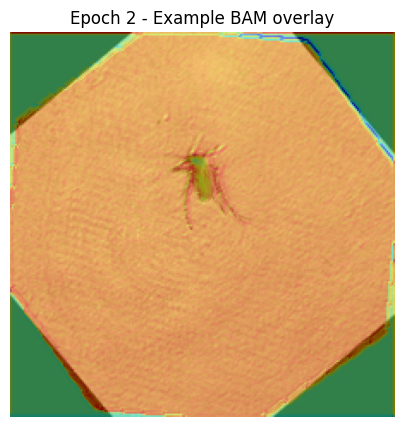

Smoke test finished.


In [ ]:
# ---------------------------
# BIPA model + smoke test
# ---------------------------
import torch, math, time
import torch.nn as nn
from torch.optim import AdamW
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)

# ---- Config (adjustable) ----
IMG_SIZE = 224
PATCH_SIZE = 16       # same as DataLoader config
EMBED_DIM = 256
DEPTH = 6
NUM_HEADS = 8
MLP_RATIO = 4.0
ALPHA_INIT = 1.0
PRINT_EVERY = 5

NUM_CLASSES = len(label2idx)  # label2idx from your dataset cell

# ------------------------
# Patch embedding (conv-based)
# ------------------------
class PatchEmbed(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=3, embed_dim=EMBED_DIM):
        super().__init__()
        self.patch_size = patch_size
        self.n_h = img_size // patch_size
        self.n_w = img_size // patch_size
        self.num_patches = self.n_h * self.n_w
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.num_patches, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        x = self.proj(x)  # (B, E, H/ps, W/ps)
        B, E, Hf, Wf = x.shape
        x = x.flatten(2).transpose(1, 2)  # (B, N, E)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        return x

# ------------------------
# A-BAMNet (small CNN -> raw map H x W)
# ------------------------
class ABAMNet(nn.Module):
    def __init__(self, in_ch=3, base_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base_ch, 3, padding=1), nn.ReLU(),
            nn.Conv2d(base_ch, base_ch, 3, padding=1), nn.ReLU(),
            nn.Conv2d(base_ch, 1, 1)  # single-channel raw map
        )
        # init
        for m in self.net.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        # x: (B,3,H,W)
        raw = self.net(x)  # (B,1,H,W)
        return raw.squeeze(1)  # (B,H,W)

# ------------------------
# BIPA Multi-head Attention
# ------------------------
class BIPA_MultiHeadAttention(nn.Module):
    def __init__(self, dim=EMBED_DIM, num_heads=NUM_HEADS):
        super().__init__()
        self.num_heads = num_heads
        self.dk = dim // num_heads
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.alpha = nn.Parameter(torch.tensor(ALPHA_INIT, dtype=torch.float32))

    def forward(self, x, mb):
        # x: (B, 1+N, D), mb: (B, N) in [0,1]
        B, L, D = x.shape
        qkv = self.qkv(x).reshape(B, L, 3, self.num_heads, self.dk).permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # each (B, heads, L, dk)
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.dk)  # (B, heads, L, L)

        # prefix zero for cls token so it doesn't get MB bias
        cls_zero = torch.zeros(B, 1, device=mb.device, dtype=mb.dtype)
        mb_with_cls = torch.cat([cls_zero, mb], dim=1)  # (B,1+N)

        # expand to (B, heads, L, L)
        mb_exp = mb_with_cls.unsqueeze(1).unsqueeze(2)  # (B,1,1,1+N)
        mb_exp = mb_exp.expand(-1, self.num_heads, L, L)

        scores = scores + self.alpha * mb_exp

        att = torch.softmax(scores, dim=-1)
        out = (att @ v).transpose(1,2).reshape(B, L, D)
        out = self.proj(out)
        return out

# ------------------------
# Transformer block using BIPA attention (pre-norm)
# ------------------------
class BIPABlock(nn.Module):
    def __init__(self, dim=EMBED_DIM, num_heads=NUM_HEADS, mlp_ratio=MLP_RATIO):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = BIPA_MultiHeadAttention(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim*mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim*mlp_ratio), dim),
        )

    def forward(self, x, mb):
        x = x + self.attn(self.norm1(x), mb)
        x = x + self.mlp(self.norm2(x))
        return x

# ------------------------
# Full BIPA model
# ------------------------
class BIPA(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_ch=3, embed_dim=EMBED_DIM, depth=DEPTH, num_heads=NUM_HEADS, num_classes=NUM_CLASSES):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_ch, embed_dim)
        self.abam = ABAMNet(in_ch=in_ch)
        self.blocks = nn.ModuleList([BIPABlock(embed_dim, num_heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        self.patch_size = patch_size

    def forward(self, x):
        B = x.shape[0]
        tokens = self.patch_embed(x)        # (B, 1+N, D)
        raw_map = self.abam(x)              # (B, H, W)
        # average raw_map per patch
        ps = self.patch_size
        H, W = raw_map.shape[1], raw_map.shape[2]
        raw_reshaped = raw_map.view(B, H//ps, ps, W//ps, ps).mean(dim=(2,4))  # (B, H/ps, W/ps)
        mb = torch.sigmoid(raw_reshaped.flatten(1))  # (B, N) in (0,1)
        for blk in self.blocks:
            tokens = blk(tokens, mb)
        cls = tokens[:, 0]
        cls = self.norm(cls)
        logits = self.head(cls)
        return logits, raw_map, mb

# ------------------------
# Visualization helper: overlay raw_map on PIL image
# ------------------------
def visualize_bam_on_pil(pil_img, raw_map, alpha=0.5, cmap='jet'):
    # pil_img: PIL.Image, raw_map: HxW numpy
    img = np.array(pil_img.resize(raw_map.shape[::-1]))  # resize PIL to raw_map shape
    m = raw_map - raw_map.min()
    if m.max() > 0:
        m = m / (m.max() + 1e-8)
    cmap_fn = plt.get_cmap(cmap)
    colored = (cmap_fn(m)[:, :, :3] * 255).astype(np.uint8)
    blended = (img * (1-alpha) + colored * alpha).astype(np.uint8)
    return blended

# ------------------------
# Smoke test: overfit tiny loader
# ------------------------
def smoke_test_overfit(model, loader, device=DEVICE, epochs=3, steps_per_epoch=8):
    model.to(device)
    opt = AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
    criterion = nn.CrossEntropyLoss()
    model.train()
    for ep in range(epochs):
        t0 = time.time()
        total_loss = 0.0
        for i, batch in enumerate(loader):
            images, labels, pil_images, paths = batch  # our custom_collate returns this
            images = images.to(device)
            labels = labels.to(device)
            logits, raw_map, mb = model(images)
            loss = criterion(logits, labels)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()
            if (i+1) % PRINT_EVERY == 0:
                print(f"Epoch {ep+1} Step {i+1} avg loss {(total_loss/PRINT_EVERY):.4f}")
                total_loss = 0.0
            if i >= steps_per_epoch - 1:
                break
        print(f"Epoch {ep+1} time: {time.time()-t0:.1f}s")
        # visualize BAM for first image in the last batch
        model.eval()
        with torch.no_grad():
            sample_raw = raw_map[0].detach().cpu().numpy()
            pil = pil_images[0]  # original PIL image from dataset
            blended = visualize_bam_on_pil(pil, sample_raw, alpha=0.5)
            plt.figure(figsize=(5,5))
            plt.imshow(blended)
            plt.title(f"Epoch {ep+1} - Example BAM overlay")
            plt.axis('off')
            plt.show()
        model.train()
    print("Smoke test finished.")

# ------------------------
# Run smoke test
# ------------------------
model = BIPA()
print("Model parameters (M):", sum(p.numel() for p in model.parameters())/1e6)
# small loader: use train_loader but smaller batch for quick run
small_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=8, shuffle=True, num_workers=0, collate_fn=custom_collate
)
smoke_test_overfit(model, small_loader, epochs=2, steps_per_epoch=8)


In [ ]:
# Run this cell first in Colab if you want YOLO support.
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.5 MB/s eta 0:00:00


In [ ]:
# Full pipeline: YOLO preprocessing  + BIPA training & evaluation
# Paste this after you ran and tested the DataLoader cell previously.
# !pip install -q ultralytics
# -------------------------
# 1) Install ultralytics if you want to use YOLO in Colab
# -------------------------

# -------------------------
# Imports
# -------------------------
import os, time, math, shutil
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Use variables from your DataLoader/previous cells:
# DRIVE_ROOT, train_csv, test_csv, label2idx, idx2label, train_transform, test_transform, MosquitoDataset, custom_collate, train_loader, test_loader
# If those are not in scope, re-import or re-run the DataLoader cell first.

# -------------------------
# Config (edit if needed)
# -------------------------
YOLO_WEIGHTS = None   # <-- set path to your custom YOLO .pt file if available, e.g. "/content/drive/MyDrive/yolo_mosquito.pt"
USE_ULTRALYTICS = True  # set False to skip using ultralytics even if installed
CROP_DIR = os.path.join(DRIVE_ROOT, "crops_v1")   # where cropped images will be stored
CROPPED_TRAIN_CSV = os.path.join(CROP_DIR, "d1_train_crops.csv")
CROPPED_TEST_CSV  = os.path.join(CROP_DIR, "d1_test_crops.csv")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Training params
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 25
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.05
BEST_MODEL_PATH = "/content/drive/MyDrive/Model Weights Efficient-VIT : paper04/Dataset_2/BIPA_best_dataset2.pth"  # adjust as needed

print("Device:", DEVICE)

# -------------------------
# 2) YOLO cropping helper
# -------------------------


def run_yolo_and_save_crops(csv_in, csv_out, crop_dir, yolo_weights=None, conf_thres=0.3, device='0'):
    os.makedirs(crop_dir, exist_ok=True)
    df = pd.read_csv(csv_in).copy()
    out_rows = []

    try:
        if yolo_weights is not None and USE_ULTRALYTICS:
            from ultralytics import YOLO
            model = YOLO(yolo_weights)
            print("Loaded YOLO model:", yolo_weights)
            use_yolo = True
        else:
            print("YOLO disabled — using center-crop fallback.")
            use_yolo = False
    except Exception as e:
        print("Ultralytics unavailable. Using center-crop fallback.", e)
        use_yolo = False

    for i, row in df.iterrows():
        src_path = str(row['filepath'])
        label = row['label']

        # -------------------------
        # FIX 1: Robust path replacement
        # -------------------------
        src_path = src_path.replace("../Dataset_2", DRIVE_ROOT)

        try:
            if use_yolo:
                # YOLO inference (skipped because you have no weights)
                res = model(src_path, imgsz=640, conf=conf_thres, device=device, verbose=False)
                boxes = res[0].boxes
                if boxes is None or len(boxes) == 0:
                    raise RuntimeError("No YOLO detections, fallback to center-crop")

                xyxy = boxes.xyxy.cpu().numpy()
                x1, y1, x2, y2 = xyxy[0, :4].astype(int)
                img = Image.open(src_path).convert('RGB')
                crop = img.crop((x1, y1, x2, y2))

            else:
                # -------------------------
                # FIX 2: Pure center-crop only
                # -------------------------
                img = Image.open(src_path).convert('RGB')
                w, h = img.size
                side = int(min(w, h) * 0.9)
                left = max(0, (w - side) // 2)
                top = max(0, (h - side) // 2)
                crop = img.crop((left, top, left + side, top + side))

        except Exception as e:
            print("Error loading:", src_path, "→ fallback center-crop", e)
            img = Image.open(src_path).convert('RGB')
            w, h = img.size
            side = int(min(w, h) * 0.9)
            left = max(0, (w - side) // 2)
            top = max(0, (h - side) // 2)
            crop = img.crop((left, top, left + side, top + side))

        # save crop
        save_name = f"{i:06d}_{os.path.basename(src_path)}"
        save_path = os.path.join(crop_dir, save_name)
        crop = crop.resize((IMG_SIZE, IMG_SIZE))
        crop.save(save_path)
        out_rows.append({"filepath": save_path, "label": label})

        if (i + 1) % 50 == 0:
            print(f"Processed {i+1}/{len(df)}")

    pd.DataFrame(out_rows).to_csv(csv_out, index=False)
    print("Saved:", csv_out)
    return out_rows

# -------------------------
# 3) Run YOLO preprocessing (only if crops not already created)
# -------------------------
if not os.path.exists(CROP_DIR) or len(os.listdir(CROP_DIR)) == 0:
    print("Crops directory missing or empty. Running preprocessing...")
    # process train and test CSVs
    _ = run_yolo_and_save_crops(train_csv, CROPPED_TRAIN_CSV, os.path.join(CROP_DIR, "train"), yolo_weights=YOLO_WEIGHTS, device='0')
    _ = run_yolo_and_save_crops(test_csv, CROPPED_TEST_CSV, os.path.join(CROP_DIR, "test"), yolo_weights=YOLO_WEIGHTS, device='0')
else:
    print("Crops already exist; skipping YOLO preprocessing. If you want to re-run, delete crop_dir and re-run this cell.")

# -------------------------
# 4) Create Datasets/Loaders using cropped CSVs
# -------------------------
# Update paths to point to new cropped CSV files if available
train_csv_used = CROPPED_TRAIN_CSV if os.path.exists(CROPPED_TRAIN_CSV) else train_csv
test_csv_used  = CROPPED_TEST_CSV  if os.path.exists(CROPPED_TEST_CSV)  else test_csv

# instantiate MosquitoDataset with cropped csvs - reusing transforms and label map
train_dataset_crops = MosquitoDataset(train_csv_used, label2idx, transform=train_transform, return_pil=True,
                                     root_replace_from=DRIVE_ROOT, root_replace_to=DRIVE_ROOT)
test_dataset_crops  = MosquitoDataset(test_csv_used, label2idx, transform=test_transform, return_pil=True,
                                     root_replace_from=DRIVE_ROOT, root_replace_to=DRIVE_ROOT)

train_loader_crops = DataLoader(train_dataset_crops, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
                                pin_memory=True, collate_fn=custom_collate)
test_loader_crops  = DataLoader(test_dataset_crops, batch_size=BATCH_SIZE, shuffle=False, num_workers=2,
                                pin_memory=True, collate_fn=custom_collate)

print("Cropped datasets ready. Train size:", len(train_dataset_crops), "Test size:", len(test_dataset_crops))




In [ ]:
# !rm -r "/content/drive/MyDrive/Dataset_2/crops_v2"
#

rm: cannot remove '/content/drive/MyDrive/Dataset_2/crops_v2': No such file or directory


In [ ]:
# -------------------------
# 5) BIPA model (reuse previous model code)
# -------------------------
# Paste the BIPA model classes here (PatchEmbed, ABAMNet, BIPA_MultiHeadAttention, BIPABlock, BIPA)
# For brevity, we re-create minimal definitions (copy earlier model definitions or re-import if you defined them)
# (I'll re-define compactly)
class PatchEmbed(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=8, in_chans=3, embed_dim=256):
        super().__init__()
        self.patch_size = patch_size
        self.n_h = img_size // patch_size
        self.n_w = img_size // patch_size
        self.num_patches = self.n_h * self.n_w
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.num_patches, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        x = self.proj(x)
        B, E, Hf, Wf = x.shape
        x = x.flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        return x

class ABAMNet(nn.Module):
    def __init__(self, in_ch=3, base_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base_ch, 3, padding=1), nn.ReLU(),
            nn.Conv2d(base_ch, base_ch, 3, padding=1), nn.ReLU(),
            nn.Conv2d(base_ch, 1, 1)
        )

    def forward(self, x):
        raw = self.net(x)
        return raw.squeeze(1)

class BIPA_MultiHeadAttention(nn.Module):
    def __init__(self, dim=256, num_heads=8):
        super().__init__()
        self.num_heads = num_heads
        self.dk = dim // num_heads
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.alpha = nn.Parameter(torch.tensor(1.0))

    def forward(self, x, mb):
        B, L, D = x.shape
        qkv = self.qkv(x).reshape(B, L, 3, self.num_heads, self.dk).permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.dk)
        cls_zero = torch.zeros(B, 1, device=mb.device, dtype=mb.dtype)
        mb_with_cls = torch.cat([cls_zero, mb], dim=1)
        mb_exp = mb_with_cls.unsqueeze(1).unsqueeze(2).expand(-1, self.num_heads, L, L)
        scores = scores + self.alpha * mb_exp
        att = torch.softmax(scores, dim=-1)
        out = (att @ v).transpose(1,2).reshape(B, L, D)
        out = self.proj(out)
        return out

class BIPABlock(nn.Module):
    def __init__(self, dim=256, num_heads=8, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = BIPA_MultiHeadAttention(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, int(dim*mlp_ratio)), nn.GELU(), nn.Linear(int(dim*mlp_ratio), dim))

    def forward(self, x, mb):
        x = x + self.attn(self.norm1(x), mb)
        x = x + self.mlp(self.norm2(x))
        return x

class BIPA(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=16, in_ch=3, embed_dim=256, depth=6, num_heads=8, num_classes=len(label2idx)):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_ch, embed_dim)
        self.abam = ABAMNet(in_ch=in_ch)
        self.blocks = nn.ModuleList([BIPABlock(embed_dim, num_heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        self.patch_size = patch_size

    def forward(self, x):
        B = x.shape[0]
        tokens = self.patch_embed(x)
        raw_map = self.abam(x)
        ps = self.patch_size
        H, W = raw_map.shape[1], raw_map.shape[2]
        raw_reshaped = raw_map.view(B, H//ps, ps, W//ps, ps).mean(dim=(2,4))
        mb = torch.sigmoid(raw_reshaped.flatten(1))
        for blk in self.blocks:
            tokens = blk(tokens, mb)
        cls = tokens[:, 0]
        cls = self.norm(cls)
        logits = self.head(cls)
        return logits, raw_map, mb

# -------------------------
# 6) Training + validation loops with sklearn metrics and logging formats
# -------------------------
def evaluate_model(model, loader, device=DEVICE):
    model.eval()
    preds = []
    gts = []
    times = []
    with torch.no_grad():
        for images, labels, pils, paths in loader:
            images = images.to(device)
            t0 = time.time()
            logits, raw_map, mb = model(images)
            t1 = time.time()
            times.append((t1 - t0) / images.shape[0])  # seconds per image
            ypred = logits.argmax(dim=1).detach().cpu().numpy()
            preds.extend(list(ypred))
            gts.extend(list(labels.numpy()))
    # metrics
    acc = accuracy_score(gts, preds)
    prec = precision_score(gts, preds, average='macro', zero_division=0)
    rec = recall_score(gts, preds, average='macro', zero_division=0)
    f1 = f1_score(gts, preds, average='macro', zero_division=0)
    avg_infer_ms = np.mean(times) * 1000.0
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "infer_ms": avg_infer_ms}

def train_and_validate(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, device=DEVICE, best_model_path=BEST_MODEL_PATH):
    model.to(device)
    opt = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    best_val_f1 = -1.0
    history = []

    for ep in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        all_preds = []
        all_gts = []
        t0_epoch = time.time()
        for i, batch in enumerate(train_loader):
            images, labels, pils, paths = batch
            images = images.to(device)
            labels = labels.to(device)
            logits, raw_map, mb = model(images)
            loss = criterion(logits, labels)
            opt.zero_grad()
            loss.backward()
            opt.step()
            running_loss += loss.item()

            # collect for batch metrics
            preds_batch = logits.argmax(dim=1).detach().cpu().numpy()
            all_preds.extend(list(preds_batch))
            all_gts.extend(list(labels.detach().cpu().numpy()))

            if (i+1) % 20 == 0:
                avg_loss = running_loss / 20
                batch_acc = accuracy_score(all_gts, all_preds)
                print(f"Epoch [{ep}/{epochs}] Step {i+1} - Loss(avg last 20): {avg_loss:.4f}, Acc_so_far: {batch_acc*100:.2f}%")
                running_loss = 0.0
                all_preds = []
                all_gts = []

        elapsed = time.time() - t0_epoch
        # End of epoch training metrics
        train_acc = accuracy_score(all_gts, all_preds) if len(all_gts)>0 else 0.0
        print(f"Epoch [{ep}/{epochs}] Loss: {loss.item():.4f}, Accuracy: {train_acc*100:.2f}%")
        # validate
        val_metrics = evaluate_model(model, val_loader, device=device)
        print("Test Results")
        print(f"Accuracy: {val_metrics['accuracy']*100:.2f}%")
        print(f"Precision: {val_metrics['precision']:.4f}")
        print(f"Recall: {val_metrics['recall']:.4f}")
        print(f"F1 Score: {val_metrics['f1']:.4f}")

        # Also print the structured model dict per your required format
        model_dict = {
            "Model": f"BIPA_epoch{ep}",
            "Accuracy (%)": round(val_metrics['accuracy']*100, 2),
            "Precision": round(val_metrics['precision'], 4),
            "Recall": round(val_metrics['recall'], 4),
            "F1 Score": round(val_metrics['f1'], 4),
            "Inference (ms)": round(val_metrics['infer_ms'], 2)
        }
        print(f"Dataset-1\nEvaluating model {model_dict['Model']}...")
        print(".............................................")
        print(model_dict)
        print(".............................................")
        print("")

        # save best by val f1
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved new best model to {best_model_path} (val F1: {best_val_f1:.4f})")

        history.append({"epoch": ep, "val": val_metrics})

    return history

# -------------------------
# 7) Instantiate model + run training
# -------------------------
model = BIPA()
print("Model params (M):", sum(p.numel() for p in model.parameters())/1e6)

history = train_and_validate(model, train_loader_crops, test_loader_crops, epochs=EPOCHS, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, device=DEVICE, best_model_path=BEST_MODEL_PATH)

# -------------------------
# 8) Final evaluation using best saved model
# -------------------------
print("Loading best model and evaluating on test set...")
best_model = BIPA()
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
best_model.to(DEVICE)

final_metrics = evaluate_model(best_model, test_loader_crops, device=DEVICE)
print(".............................................")
print("Final Test Results")
print(f"Accuracy: {final_metrics['accuracy']*100:.2f}%")
print(f"Precision: {final_metrics['precision']:.4f}")
print(f"Recall: {final_metrics['recall']:.4f}")
print(f"F1 Score: {final_metrics['f1']:.4f}")
print(f"Inference (ms per image): {final_metrics['infer_ms']:.2f} ms")
print(".............................................")




print("____________________________________________")


# Print final dictionary summary in required format
final_summary = {
    'Model': 'BIPA_best_dataset1',
    'Accuracy (%)': round(final_metrics['accuracy']*100, 2),
    'Precision': round(final_metrics['precision'], 4),
    'Recall': round(final_metrics['recall'], 4),
    'F1 Score': round(final_metrics['f1'], 4),
    'Inference (ms)': round(final_metrics['infer_ms'], 2)
}
print("Dataset-1\nEvaluating model BIPA_best_dataset1...")
print(final_summary)

Model params (M): 4.997578
Epoch [1/25] Step 20 - Loss(avg last 20): 1.2043, Acc_so_far: 41.25%
Epoch [1/25] Loss: 0.9950, Accuracy: 33.33%
Test Results
Accuracy: 39.33%
Precision: 0.4478
Recall: 0.4489
F1 Score: 0.3523
Dataset-1
Evaluating model BIPA_epoch1...
.............................................
{'Model': 'BIPA_epoch1', 'Accuracy (%)': 39.33, 'Precision': 0.4478, 'Recall': 0.4489, 'F1 Score': 0.3523, 'Inference (ms)': np.float64(0.95)}
.............................................

Saved new best model to /content/drive/MyDrive/Model Weights Efficient-VIT : paper04/Dataset_1/BIPA_best_dataset1.pth (val F1: 0.3523)
Epoch [2/25] Step 20 - Loss(avg last 20): 1.0979, Acc_so_far: 43.44%
Epoch [2/25] Loss: 0.9356, Accuracy: 42.42%
Test Results
Accuracy: 42.70%
Precision: 0.2845
Recall: 0.4154
F1 Score: 0.3352
Dataset-1
Evaluating model BIPA_epoch2...
.............................................
{'Model': 'BIPA_epoch2', 'Accuracy (%)': 42.7, 'Precision': 0.2845, 'Recall': 0.4154, 

## Detailed Methodology

In [ ]:

# -------------------------
# INSTALLATION (Run once)
# -------------------------
!pip install -q ultralytics opencv-python scikit-image


In [ ]:
# ====================================================================
# COMPLETE BIPA PIPELINE FOR MOSQUITO CLASSIFICATION
# Includes: YOLO preprocessing + Heuristic BAM + End-to-End Training
# ====================================================================

# -------------------------
# IMPORTS
# -------------------------
import os, time, math, shutil
import pandas as pd
import numpy as np
from PIL import Image
import cv2
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from skimage.filters import gabor_kernel
from scipy import ndimage as ndi
import seaborn as sns

# -------------------------
# CONFIG
# -------------------------
DRIVE_ROOT = "/content/drive/MyDrive/Dataset_3"
IMG_SIZE = 224
PATCH_SIZE = 8  # CRITICAL: Micro-patches for fine-grained features
BATCH_SIZE = 16
EPOCHS = 30  # Increased for better convergence
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01
NUM_WORKERS = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paths
train_csv = os.path.join(DRIVE_ROOT, "d3_train_fixed.csv")
test_csv = os.path.join(DRIVE_ROOT, "d3_test_fixed.csv")
CROP_DIR = os.path.join(DRIVE_ROOT, "crops_yolo")
CROPPED_TRAIN_CSV = os.path.join(CROP_DIR, "d3_train_crops.csv")
CROPPED_TEST_CSV = os.path.join(CROP_DIR, "d3_test_crops.csv")
BEST_MODEL_PATH = os.path.join(DRIVE_ROOT, "BIPA_best.pth")

# Model architecture (optimized for small dataset)
EMBED_DIM = 128
DEPTH = 4
NUM_HEADS = 8
MLP_RATIO = 4.0

print(f"Device: {DEVICE}")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Patch Size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"Number of patches: {(IMG_SIZE//PATCH_SIZE)**2}")


# -------------------------
# BUILD LABEL MAP
# -------------------------
def build_label_map(csv_paths):
    labels = []
    for p in csv_paths:
        df = pd.read_csv(p)
        labels.extend(df['label'].unique())
    labels = sorted(list(set(labels)))
    return {lab: i for i, lab in enumerate(labels)}

label2idx = build_label_map([train_csv, test_csv])
idx2label = {v: k for k, v in label2idx.items()}
NUM_CLASSES = len(label2idx)

print(f"\nLabel mapping: {label2idx}")
print(f"Number of classes: {NUM_CLASSES}")

# -------------------------
# YOLO PREPROCESSING
# -------------------------
def run_yolo_preprocessing(csv_in, csv_out, crop_dir, conf_thres=0.25):
    """
    Use YOLOv8 pretrained on COCO to detect and crop mosquitoes.
    Falls back to center crop if no detection.
    """
    os.makedirs(crop_dir, exist_ok=True)

    # Load YOLOv8 nano (fastest, sufficient for detection)
    try:
        from ultralytics import YOLO
        model = YOLO('yolov8n.pt')  # Pretrained on COCO
        print(f"✓ Loaded YOLOv8 model")
        use_yolo = True
    except Exception as e:
        print(f"✗ Could not load YOLO: {e}")
        print("  Using center-crop fallback")
        use_yolo = False

    df = pd.read_csv(csv_in).copy()
    df['filepath'] = df['filepath'].astype(str).apply(
        lambda p: p.replace("../Dataset_3", DRIVE_ROOT)
    )

    out_rows = []
    detection_count = 0

    for i, row in df.iterrows():
        src_path = row['filepath']
        label = row['label']

        try:
            img = Image.open(src_path).convert('RGB')
            w, h = img.size

            if use_yolo:
                # YOLO detection (looks for any object, prioritizes insects/animals)
                results = model(src_path, conf=conf_thres, verbose=False)
                boxes = results[0].boxes

                if boxes is not None and len(boxes) > 0:
                    # Get largest detection (most likely the mosquito)
                    areas = (boxes.xyxy[:, 2] - boxes.xyxy[:, 0]) * (boxes.xyxy[:, 3] - boxes.xyxy[:, 1])
                    largest_idx = torch.argmax(areas)
                    x1, y1, x2, y2 = boxes.xyxy[largest_idx].cpu().numpy().astype(int)

                    # Add padding (10% of box size)
                    box_w, box_h = x2 - x1, y2 - y1
                    pad_w, pad_h = int(box_w * 0.1), int(box_h * 0.1)
                    x1 = max(0, x1 - pad_w)
                    y1 = max(0, y1 - pad_h)
                    x2 = min(w, x2 + pad_w)
                    y2 = min(h, y2 + pad_h)

                    crop = img.crop((x1, y1, x2, y2))
                    detection_count += 1
                else:
                    # Fallback to center crop
                    side = int(min(w, h) * 0.9)
                    left = (w - side) // 2
                    top = (h - side) // 2
                    crop = img.crop((left, top, left + side, top + side))
            else:
                # Center crop fallback
                side = int(min(w, h) * 0.9)
                left = (w - side) // 2
                top = (h - side) // 2
                crop = img.crop((left, top, left + side, top + side))

        except Exception as e:
            print(f"Error processing {src_path}: {e}")
            # Emergency fallback
            img = Image.open(src_path).convert('RGB')
            w, h = img.size
            side = int(min(w, h) * 0.8)
            left = (w - side) // 2
            top = (h - side) // 2
            crop = img.crop((left, top, left + side, top + side))

        # Resize and save
        crop = crop.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)
        save_name = f"{i:06d}_{os.path.basename(src_path)}"
        save_path = os.path.join(crop_dir, save_name)
        crop.save(save_path, quality=95)

        out_rows.append({"filepath": save_path, "label": label})

        if (i + 1) % 50 == 0:
            print(f"  Processed {i+1}/{len(df)}")

    # Save cropped CSV
    pd.DataFrame(out_rows).to_csv(csv_out, index=False)
    print(f"✓ Saved: {csv_out}")
    if use_yolo:
        print(f"  YOLO detections: {detection_count}/{len(df)} ({100*detection_count/len(df):.1f}%)")

    return out_rows

# Run YOLO preprocessing
if not os.path.exists(CROPPED_TRAIN_CSV) or not os.path.exists(CROPPED_TEST_CSV):
    print("\n" + "="*60)
    print("STEP 1: YOLO PREPROCESSING")
    print("="*60)

    print("\nProcessing training set...")
    _ = run_yolo_preprocessing(train_csv, CROPPED_TRAIN_CSV,
                                os.path.join(CROP_DIR, "train"))

    print("\nProcessing test set...")
    _ = run_yolo_preprocessing(test_csv, CROPPED_TEST_CSV,
                               os.path.join(CROP_DIR, "test"))
else:
    print("\n✓ Crops already exist, skipping YOLO preprocessing")

# -------------------------
# HEURISTIC BAM FILTERS
# -------------------------
class HeuristicBAMFilters:
    """
    Bio-inspired filters for extracting texture, edges, and contours.
    These serve as auxiliary input to guide A-BAMNet.
    """
    def __init__(self):
        # Gabor filters for texture (wing venation)
        self.gabor_kernels = []
        for theta in np.arange(0, np.pi, np.pi / 4):  # 4 orientations
            for frequency in [0.1, 0.2]:  # 2 frequencies
                kernel = np.real(gabor_kernel(frequency, theta=theta))
                self.gabor_kernels.append(kernel)

    def apply_gabor(self, img_gray):
        """Extract texture features using Gabor filters"""
        responses = []
        for kernel in self.gabor_kernels:
            filtered = ndi.convolve(img_gray, kernel, mode='wrap')
            responses.append(filtered)
        # Aggregate: max response across orientations
        return np.max(responses, axis=0)
    def apply_log(self, img_gray, sigma=2.0):
      img_gray_64 = img_gray.astype(np.float64)
      blurred = cv2.GaussianBlur(img_gray_64, (0, 0), sigma)
      log_filter = cv2.Laplacian(blurred, cv2.CV_64F)
      return np.abs(log_filter)

    def apply_contours(self, img_gray):
        """Contour detection for body boundaries"""
        edges = cv2.Canny((img_gray * 255).astype(np.uint8), 50, 150)
        # Dilate to make contours more prominent
        kernel = np.ones((3, 3), np.uint8)
        edges = cv2.dilate(edges, kernel, iterations=1)
        return edges.astype(np.float32) / 255.0

    def generate_heuristic_bam(self, img_pil):
        """
        Generate heuristic BAM from PIL image
        Returns: H x W feature map highlighting biological regions
        """
        # Convert to grayscale numpy
        img_gray = np.array(img_pil.convert('L')).astype(np.float32) / 255.0

        # Apply filters
        gabor_map = self.apply_gabor(img_gray)
        log_map = self.apply_log(img_gray)
        contour_map = self.apply_contours(img_gray)

        # Normalize each map to [0, 1]
        gabor_map = (gabor_map - gabor_map.min()) / (gabor_map.max() - gabor_map.min() + 1e-8)
        log_map = (log_map - log_map.min()) / (log_map.max() - log_map.min() + 1e-8)
        # contour_map already normalized

        # Aggregate: weighted sum (emphasize texture for mosquitoes)
        M_raw = 0.5 * gabor_map + 0.3 * log_map + 0.2 * contour_map

        # Normalize to [0, 1]
        M_raw = (M_raw - M_raw.min()) / (M_raw.max() - M_raw.min() + 1e-8)

        return M_raw

# -------------------------
# DATASET WITH HEURISTIC BAM
# -------------------------
from torchvision import transforms

NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

class MosquitoDatasetWithBAM(torch.utils.data.Dataset):
    def __init__(self, csv_file, label2idx, transform=None, generate_heuristic=True):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.label2idx = label2idx
        self.generate_heuristic = generate_heuristic

        if generate_heuristic:
            self.bam_filter = HeuristicBAMFilters()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['filepath']
        label_str = self.data.iloc[idx]['label']
        label = self.label2idx[label_str]

        # Load image
        img_pil = Image.open(img_path).convert('RGB')

        # Generate heuristic BAM if needed
        if self.generate_heuristic:
            heuristic_bam = self.bam_filter.generate_heuristic_bam(img_pil)
            heuristic_bam = torch.from_numpy(heuristic_bam).float()
        else:
            heuristic_bam = torch.zeros((IMG_SIZE, IMG_SIZE), dtype=torch.float32)

        # Apply transforms
        img_tensor = self.transform(img_pil)

        return img_tensor, label, heuristic_bam, img_path

# Create datasets
train_dataset = MosquitoDatasetWithBAM(
    CROPPED_TRAIN_CSV, label2idx, transform=train_transform, generate_heuristic=True
)
test_dataset = MosquitoDatasetWithBAM(
    CROPPED_TEST_CSV, label2idx, transform=test_transform, generate_heuristic=True
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"\n✓ Datasets ready:")
print(f"  Train: {len(train_dataset)} samples")
print(f"  Test: {len(test_dataset)} samples")

# -------------------------
# BIPA MODEL COMPONENTS
# -------------------------

class PatchEmbed(nn.Module):
    """Micro-patch embedding with learnable positional encoding"""
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=3, embed_dim=EMBED_DIM):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches_side = img_size // patch_size
        self.num_patches = self.n_patches_side ** 2

        # Convolutional projection (more efficient than linear)
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

        # Learnable CLS token and positional embeddings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.num_patches, embed_dim))

        # Initialize
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        # Patch projection: (B, 3, H, W) -> (B, E, H/P, W/P)
        x = self.proj(x)
        # Flatten patches: (B, E, H/P, W/P) -> (B, E, N)
        x = x.flatten(2).transpose(1, 2)  # (B, N, E)

        # Add CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, 1+N, E)

        # Add positional embedding
        x = x + self.pos_embed

        return x

class ABAMNet(nn.Module):
    """
    Adaptive BAM Generator with heuristic feature injection.
    Takes RGB image + heuristic BAM as input, outputs learned BAM.
    """
    def __init__(self, in_ch=3, base_ch=32, use_heuristic=True):
        super().__init__()
        self.use_heuristic = use_heuristic

        # If using heuristic, concatenate as additional channel
        input_channels = in_ch + 1 if use_heuristic else in_ch

        self.conv1 = nn.Sequential(
            nn.Conv2d(input_channels, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch // 2, 3, padding=1),
            nn.BatchNorm2d(base_ch // 2),
            nn.ReLU(inplace=True)
        )

        # Output single channel attention map
        self.out = nn.Conv2d(base_ch // 2, 1, 1)

    def forward(self, x, heuristic_bam=None):
        """
        x: (B, 3, H, W) - RGB image
        heuristic_bam: (B, H, W) - heuristic feature map
        Returns: (B, H, W) - learned attention map
        """
        if self.use_heuristic and heuristic_bam is not None:
            # Concatenate heuristic as additional channel
            heuristic_bam = heuristic_bam.unsqueeze(1)  # (B, 1, H, W)
            x = torch.cat([x, heuristic_bam], dim=1)  # (B, 4, H, W)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.out(x)

        return x.squeeze(1)  # (B, H, W)

class BIPA_MultiHeadAttention(nn.Module):
    """Multi-head attention with BAM modulation"""
    def __init__(self, dim=EMBED_DIM, num_heads=NUM_HEADS, qkv_bias=True, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

        # Learnable alpha for BAM influence
        self.alpha = nn.Parameter(torch.ones(1))

    def forward(self, x, mb):
        """
        x: (B, 1+N, D) - patch tokens
        mb: (B, N) - BAM weights for N patches
        """
        B, L, D = x.shape

        # Generate Q, K, V
        qkv = self.qkv(x).reshape(B, L, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Attention scores
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, H, L, L)

        # BAM modulation: add bias to attention scores
        # CLS token gets zero bias, patches get mb values
        cls_zero = torch.zeros(B, 1, device=mb.device, dtype=mb.dtype)
        mb_with_cls = torch.cat([cls_zero, mb], dim=1)  # (B, 1+N)

        # Expand for multi-head and broadcasting
        mb_bias = mb_with_cls.unsqueeze(1).unsqueeze(2)  # (B, 1, 1, 1+N)
        mb_bias = mb_bias.expand(-1, self.num_heads, L, -1)  # (B, H, L, 1+N)

        # Add BAM bias to attention scores
        attn = attn + self.alpha * mb_bias

        # Softmax
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        # Weighted sum
        x = (attn @ v).transpose(1, 2).reshape(B, L, D)
        x = self.proj(x)
        x = self.proj_drop(x)

        return x

class BIPABlock(nn.Module):
    """BIPA Transformer encoder block"""
    def __init__(self, dim=EMBED_DIM, num_heads=NUM_HEADS, mlp_ratio=MLP_RATIO,
                 drop=0.0, attn_drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = BIPA_MultiHeadAttention(dim, num_heads, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)

        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(mlp_hidden_dim, dim),
            nn.Dropout(drop)
        )

    def forward(self, x, mb):
        # Attention with residual
        x = x + self.attn(self.norm1(x), mb)
        # MLP with residual
        x = x + self.mlp(self.norm2(x))
        return x

class BIPA(nn.Module):
    """Complete BIPA Model"""
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=3,
                 num_classes=NUM_CLASSES, embed_dim=EMBED_DIM, depth=DEPTH,
                 num_heads=NUM_HEADS, mlp_ratio=MLP_RATIO, drop_rate=0.1):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # Patch embedding
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)

        # Adaptive BAM Generator
        self.abam = ABAMNet(in_ch=in_chans, base_ch=32, use_heuristic=True)

        # BIPA Encoder blocks
        self.blocks = nn.ModuleList([
            BIPABlock(embed_dim, num_heads, mlp_ratio, drop_rate, drop_rate)
            for _ in range(depth)
        ])

        # Final normalization and classifier
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        # Dropout for regularization
        self.pos_drop = nn.Dropout(p=drop_rate)

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward(self, x, heuristic_bam=None):
        """
        x: (B, 3, H, W)
        heuristic_bam: (B, H, W) - optional heuristic BAM
        """
        B = x.shape[0]

        # Patch embedding
        tokens = self.patch_embed(x)  # (B, 1+N, D)
        tokens = self.pos_drop(tokens)

        # Generate adaptive BAM
        raw_bam = self.abam(x, heuristic_bam)  # (B, H, W)

        # Patch-level averaging: align BAM with patches
        ps = self.patch_size
        H, W = raw_bam.shape[1], raw_bam.shape[2]

        # Reshape to patches and average
        bam_patches = raw_bam.unfold(1, ps, ps).unfold(2, ps, ps)  # (B, H/ps, W/ps, ps, ps)
        bam_patches = bam_patches.contiguous().view(B, -1, ps * ps)  # (B, N, ps*ps)
        mb = bam_patches.mean(dim=2)  # (B, N)

        # Normalize with sigmoid
        mb = torch.sigmoid(mb)

        # Pass through BIPA blocks
        for block in self.blocks:
            tokens = block(tokens, mb)

        # Extract CLS token and classify
        cls_token = tokens[:, 0]
        cls_token = self.norm(cls_token)
        logits = self.head(cls_token)

        return logits, raw_bam, mb

# -------------------------
# TRAINING & EVALUATION
# -------------------------

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch_idx, (images, labels, heuristic_bams, paths) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)
        heuristic_bams = heuristic_bams.to(device)

        # Forward
        logits, raw_bam, mb = model(images, heuristic_bams)
        loss = criterion(logits, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        running_loss += loss.item()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc

def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    inference_times = []

    with torch.no_grad():
        for images, labels, heuristic_bams, paths in loader:
            images = images.to(device)
            heuristic_bams = heuristic_bams.to(device)

            # Measure inference time
            torch.cuda.synchronize() if torch.cuda.is_available() else None
            t0 = time.time()

            logits, raw_bam, mb = model(images, heuristic_bams)

            torch.cuda.synchronize() if torch.cuda.is_available() else None
            t1 = time.time()

            inference_times.append((t1 - t0) / images.shape[0])

            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    # Compute metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    avg_infer_ms = np.mean(inference_times) * 1000

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'infer_ms': avg_infer_ms,
        'predictions': all_preds,
        'labels': all_labels
    }

def train_and_validate(model, train_loader, test_loader, epochs, lr, weight_decay, device, save_path):
    """Complete training loop with validation"""
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_f1 = -1.0
    history = {'train_loss': [], 'train_acc': [], 'val_metrics': []}

    print("\n" + "="*60)
    print("STARTING TRAINING")
    print("="*60)

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch [{epoch}/{epochs}]")
        print("-" * 40)

        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        # Validate
        val_metrics = evaluate_model(model, test_loader, device)

        # Update scheduler
        scheduler.step()

        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_metrics'].append(val_metrics)

        # Print results
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"Val Acc: {val_metrics['accuracy']*100:.2f}% | "
              f"Precision: {val_metrics['precision']:.4f} | "
              f"Recall: {val_metrics['recall']:.4f} | "
              f"F1: {val_metrics['f1']:.4f}")

        # Save best model
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            torch.save(model.state_dict(), save_path)
            print(f"✓ Best model saved (F1: {best_f1:.4f})")

    return history

# -------------------------
# MAIN EXECUTION
# -------------------------

print("\n" + "="*60)
print("STEP 2: MODEL INITIALIZATION")
print("="*60)

model = BIPA(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_chans=3,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    drop_rate=0.1
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel: BIPA")
print(f"Total parameters: {total_params:,} ({total_params/1e6:.2f}M)")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/1e6:.2f}M)")
print(f"Patch size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"Number of patches: {(IMG_SIZE//PATCH_SIZE)**2}")
print(f"Embed dim: {EMBED_DIM}")
print(f"Depth: {DEPTH} blocks")
print(f"Num heads: {NUM_HEADS}")

# -------------------------
# TRAIN MODEL
# -------------------------

print("\n" + "="*60)
print("STEP 3: TRAINING")
print("="*60)

history = train_and_validate(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    device=DEVICE,
    save_path=BEST_MODEL_PATH
)

# -------------------------
# FINAL EVALUATION
# -------------------------

print("\n" + "="*60)
print("STEP 4: FINAL EVALUATION")
print("="*60)

# Load best model
best_model = BIPA(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_chans=3,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    drop_rate=0.1
)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
best_model.to(DEVICE)

final_metrics = evaluate_model(best_model, test_loader, DEVICE)

print("\n" + "="*60)
print("FINAL TEST RESULTS")
print("="*60)
print(f"Accuracy:  {final_metrics['accuracy']*100:.2f}%")
print(f"Precision: {final_metrics['precision']:.4f}")
print(f"Recall:    {final_metrics['recall']:.4f}")
print(f"F1 Score:  {final_metrics['f1']:.4f}")
print(f"Inference: {final_metrics['infer_ms']:.2f} ms/image")
print("="*60)

# Paper-style results dictionary
results_dict = {
    'Model': 'BIPA',
    'Accuracy (%)': round(final_metrics['accuracy'] * 100, 2),
    'Precision': round(final_metrics['precision'], 4),
    'Recall': round(final_metrics['recall'], 4),
    'F1 Score': round(final_metrics['f1'], 4),
    'Inference (ms)': round(final_metrics['infer_ms'], 2)
}

print("\nDataset-1")
print(f"Evaluating model BIPA...")
print(results_dict)

# -------------------------
# CONFUSION MATRIX
# -------------------------

cm = confusion_matrix(final_metrics['labels'], final_metrics['predictions'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label2idx.keys()),
            yticklabels=list(label2idx.keys()))
plt.title('Confusion Matrix - BIPA Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Confusion matrix saved to {os.path.join(DRIVE_ROOT, 'confusion_matrix.png')}")

# -------------------------
# PLOT TRAINING HISTORY
# -------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss and Accuracy
epochs_range = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss', color='b')
axes[0].tick_params(axis='y', labelcolor='b')
axes[0].grid(True, alpha=0.3)

ax2 = axes[0].twinx()
train_acc_percent = [x * 100 for x in history['train_acc']]
val_acc_percent = [x['accuracy'] * 100 for x in history['val_metrics']]
ax2.plot(epochs_range, train_acc_percent, 'g--', label='Train Acc')
ax2.plot(epochs_range, val_acc_percent, 'r--', label='Val Acc')
ax2.set_ylabel('Accuracy (%)', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.legend(loc='lower right')

axes[0].set_title('Training Progress')
axes[0].legend(loc='upper right')

# Plot 2: Validation Metrics
val_f1 = [x['f1'] for x in history['val_metrics']]
val_prec = [x['precision'] for x in history['val_metrics']]
val_rec = [x['recall'] for x in history['val_metrics']]

axes[1].plot(epochs_range, val_f1, 'b-', marker='o', label='F1 Score')
axes[1].plot(epochs_range, val_prec, 'g-', marker='s', label='Precision')
axes[1].plot(epochs_range, val_rec, 'r-', marker='^', label='Recall')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, 'training_history.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Training history saved to {os.path.join(DRIVE_ROOT, 'training_history.png')}")

# -------------------------
# VISUALIZE BAM ATTENTION
# -------------------------

def visualize_bam_attention(model, dataset, num_samples=4):
    """Visualize learned BAM attention maps"""
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*3))

    indices = np.random.choice(len(dataset), num_samples, replace=False)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            img_tensor, label, heuristic_bam, path = dataset[idx]

            # Unnormalize for display
            img_display = img_tensor.clone()
            mean = torch.tensor(NORMALIZE_MEAN).view(3, 1, 1)
            std = torch.tensor(NORMALIZE_STD).view(3, 1, 1)
            img_display = img_display * std + mean
            img_display = img_display.permute(1, 2, 0).cpu().numpy()
            img_display = np.clip(img_display, 0, 1)

            # Forward pass
            img_batch = img_tensor.unsqueeze(0).to(DEVICE)
            heuristic_batch = heuristic_bam.unsqueeze(0).to(DEVICE)
            logits, raw_bam, mb = model(img_batch, heuristic_batch)

            pred_class = logits.argmax(dim=1).item()
            true_class = label

            # Get BAM
            bam_map = raw_bam[0].cpu().numpy()
            bam_map = (bam_map - bam_map.min()) / (bam_map.max() - bam_map.min() + 1e-8)

            # Plot
            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title(f'Original\nTrue: {idx2label[true_class]}')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(heuristic_bam.cpu().numpy(), cmap='hot')
            axes[i, 1].set_title('Heuristic BAM')
            axes[i, 1].axis('off')

            axes[i, 2].imshow(img_display)
            axes[i, 2].imshow(bam_map, cmap='jet', alpha=0.5)
            axes[i, 2].set_title(f'Learned BAM\nPred: {idx2label[pred_class]}')
            axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_ROOT, 'bam_visualization.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ BAM visualization saved to {os.path.join(DRIVE_ROOT, 'bam_visualization.png')}")

print("\n" + "="*60)
print("STEP 5: VISUALIZING ATTENTION MAPS")
print("="*60)

visualize_bam_attention(best_model, test_dataset, num_samples=4)

print("\n" + "="*60)
print("PIPELINE COMPLETE!")
print("="*60)
print(f"✓ Best model saved: {BEST_MODEL_PATH}")
print(f"✓ Final F1 Score: {final_metrics['f1']:.4f}")
print(f"✓ Final Accuracy: {final_metrics['accuracy']*100:.2f}%")

Device: cuda
Image Size: 224x224
Patch Size: 8x8
Number of patches: 784

Label mapping: {'aedes': 0, 'anopheles': 1, 'culex': 2}
Number of classes: 3

STEP 1: YOLO PREPROCESSING

Processing training set...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ Loaded YOLOv8 model
  Processed 50/1200
  Processed 100/1200
  Processed 150/1200
  Processed 200/1200
  Processed 250/1200
  Processed 300/1200
  Processed 350/1200
  Processed 400/1200
  Processed 450/1200
  Processed 500/1200
  Processed 550/1200
  Processed 600/1200
  Processed 650/1200
  Processed 700/1200
  Processed 750/1200
  Processed 800/1200
  Processed 850/1200
  Processed 900/1200
  Processed 950/1200
  Processed 1000/1200
  Processed 1050/1200
  Processed 1100/12

In [6]:
# ====================================================================
# CONTINUE TRAINING FROM CHECKPOINT - STANDALONE VERSION
# ====================================================================

import os, time
import pandas as pd
import numpy as np
from PIL import Image
import cv2
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from skimage.filters import gabor_kernel
from scipy import ndimage as ndi
import seaborn as sns
from torchvision import transforms

# -------------------------
# CONFIG (REDEFINE ALL SETTINGS)
# -------------------------
DRIVE_ROOT = "/content/drive/MyDrive/Dataset_3"
IMG_SIZE = 224
PATCH_SIZE = 8
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01
NUM_WORKERS = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paths
CROP_DIR = os.path.join(DRIVE_ROOT, "crops_yolo")
CROPPED_TRAIN_CSV = os.path.join(CROP_DIR, "d3_train_crops.csv")
CROPPED_TEST_CSV = os.path.join(CROP_DIR, "d3_test_crops.csv")
BEST_MODEL_PATH = os.path.join(DRIVE_ROOT, "BIPA_best.pth")

# Model architecture
EMBED_DIM = 128
DEPTH = 4
NUM_HEADS = 8
MLP_RATIO = 4.0

print("="*60)
print("RESUMING TRAINING FROM CHECKPOINT")
print("="*60)
print(f"Device: {DEVICE}")

# -------------------------
# BUILD LABEL MAP
# -------------------------
train_csv = os.path.join(DRIVE_ROOT, "d3_train_fixed.csv")
test_csv = os.path.join(DRIVE_ROOT, "d3_test_fixed.csv")

def build_label_map(csv_paths):
    labels = []
    for p in csv_paths:
        df = pd.read_csv(p)
        labels.extend(df['label'].unique())
    labels = sorted(list(set(labels)))
    return {lab: i for i, lab in enumerate(labels)}

label2idx = build_label_map([train_csv, test_csv])
idx2label = {v: k for k, v in label2idx.items()}
NUM_CLASSES = len(label2idx)

print(f"Number of classes: {NUM_CLASSES}")

# -------------------------
# VERIFY PATHS
# -------------------------
if not os.path.exists(BEST_MODEL_PATH):
    print(f"❌ Model not found at: {BEST_MODEL_PATH}")
    print("Please check your drive path!")
else:
    print(f"✓ Model found: {BEST_MODEL_PATH}")

if not os.path.exists(CROPPED_TRAIN_CSV) or not os.path.exists(CROPPED_TEST_CSV):
    print("❌ Cropped datasets not found!")
else:
    print(f"✓ Cropped datasets found")

# -------------------------
# HEURISTIC BAM FILTERS (REDEFINE)
# -------------------------
class HeuristicBAMFilters:
    def __init__(self):
        self.gabor_kernels = []
        for theta in np.arange(0, np.pi, np.pi / 4):
            for frequency in [0.1, 0.2]:
                kernel = np.real(gabor_kernel(frequency, theta=theta))
                self.gabor_kernels.append(kernel)

    def apply_gabor(self, img_gray):
        responses = []
        for kernel in self.gabor_kernels:
            filtered = ndi.convolve(img_gray, kernel, mode='wrap')
            responses.append(filtered)
        return np.max(responses, axis=0)

    def apply_log(self, img_gray, sigma=2.0):
        img_gray_64 = img_gray.astype(np.float64)
        blurred = cv2.GaussianBlur(img_gray_64, (0, 0), sigma)
        log_filter = cv2.Laplacian(blurred, cv2.CV_64F)
        return np.abs(log_filter)

    def apply_contours(self, img_gray):
        edges = cv2.Canny((img_gray * 255).astype(np.uint8), 50, 150)
        kernel = np.ones((3, 3), np.uint8)
        edges = cv2.dilate(edges, kernel, iterations=1)
        return edges.astype(np.float32) / 255.0

    def generate_heuristic_bam(self, img_pil):
        img_gray = np.array(img_pil.convert('L')).astype(np.float32) / 255.0
        gabor_map = self.apply_gabor(img_gray)
        log_map = self.apply_log(img_gray)
        contour_map = self.apply_contours(img_gray)

        gabor_map = (gabor_map - gabor_map.min()) / (gabor_map.max() - gabor_map.min() + 1e-8)
        log_map = (log_map - log_map.min()) / (log_map.max() - log_map.min() + 1e-8)

        M_raw = 0.5 * gabor_map + 0.3 * log_map + 0.2 * contour_map
        M_raw = (M_raw - M_raw.min()) / (M_raw.max() - M_raw.min() + 1e-8)

        return M_raw

# -------------------------
# DATASET (REDEFINE)
# -------------------------
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

class MosquitoDatasetWithBAM(torch.utils.data.Dataset):
    def __init__(self, csv_file, label2idx, transform=None, generate_heuristic=True):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.label2idx = label2idx
        self.generate_heuristic = generate_heuristic
        if generate_heuristic:
            self.bam_filter = HeuristicBAMFilters()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['filepath']
        label_str = self.data.iloc[idx]['label']
        label = self.label2idx[label_str]
        img_pil = Image.open(img_path).convert('RGB')

        if self.generate_heuristic:
            heuristic_bam = self.bam_filter.generate_heuristic_bam(img_pil)
            heuristic_bam = torch.from_numpy(heuristic_bam).float()
        else:
            heuristic_bam = torch.zeros((IMG_SIZE, IMG_SIZE), dtype=torch.float32)

        img_tensor = self.transform(img_pil)
        return img_tensor, label, heuristic_bam, img_path

# -------------------------
# MODEL COMPONENTS (REDEFINE)
# -------------------------
class PatchEmbed(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=3, embed_dim=EMBED_DIM):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches_side = img_size // patch_size
        self.num_patches = self.n_patches_side ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.num_patches, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        return x

class ABAMNet(nn.Module):
    def __init__(self, in_ch=3, base_ch=32, use_heuristic=True):
        super().__init__()
        self.use_heuristic = use_heuristic
        input_channels = in_ch + 1 if use_heuristic else in_ch

        self.conv1 = nn.Sequential(
            nn.Conv2d(input_channels, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch // 2, 3, padding=1),
            nn.BatchNorm2d(base_ch // 2),
            nn.ReLU(inplace=True)
        )
        self.out = nn.Conv2d(base_ch // 2, 1, 1)

    def forward(self, x, heuristic_bam=None):
        if self.use_heuristic and heuristic_bam is not None:
            heuristic_bam = heuristic_bam.unsqueeze(1)
            x = torch.cat([x, heuristic_bam], dim=1)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.out(x)
        return x.squeeze(1)

class BIPA_MultiHeadAttention(nn.Module):
    def __init__(self, dim=EMBED_DIM, num_heads=NUM_HEADS, qkv_bias=True, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
        self.alpha = nn.Parameter(torch.ones(1))

    def forward(self, x, mb):
        B, L, D = x.shape
        qkv = self.qkv(x).reshape(B, L, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale

        cls_zero = torch.zeros(B, 1, device=mb.device, dtype=mb.dtype)
        mb_with_cls = torch.cat([cls_zero, mb], dim=1)
        mb_bias = mb_with_cls.unsqueeze(1).unsqueeze(2)
        mb_bias = mb_bias.expand(-1, self.num_heads, L, -1)
        attn = attn + self.alpha * mb_bias

        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, L, D)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class BIPABlock(nn.Module):
    def __init__(self, dim=EMBED_DIM, num_heads=NUM_HEADS, mlp_ratio=MLP_RATIO, drop=0.0, attn_drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = BIPA_MultiHeadAttention(dim, num_heads, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(mlp_hidden_dim, dim),
            nn.Dropout(drop)
        )

    def forward(self, x, mb):
        x = x + self.attn(self.norm1(x), mb)
        x = x + self.mlp(self.norm2(x))
        return x

class BIPA(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=3,
                 num_classes=NUM_CLASSES, embed_dim=EMBED_DIM, depth=DEPTH,
                 num_heads=NUM_HEADS, mlp_ratio=MLP_RATIO, drop_rate=0.1):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        self.abam = ABAMNet(in_ch=in_chans, base_ch=32, use_heuristic=True)
        self.blocks = nn.ModuleList([
            BIPABlock(embed_dim, num_heads, mlp_ratio, drop_rate, drop_rate)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        self.pos_drop = nn.Dropout(p=drop_rate)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward(self, x, heuristic_bam=None):
        B = x.shape[0]
        tokens = self.patch_embed(x)
        tokens = self.pos_drop(tokens)
        raw_bam = self.abam(x, heuristic_bam)

        ps = self.patch_size
        bam_patches = raw_bam.unfold(1, ps, ps).unfold(2, ps, ps)
        bam_patches = bam_patches.contiguous().view(B, -1, ps * ps)
        mb = bam_patches.mean(dim=2)
        mb = torch.sigmoid(mb)

        for block in self.blocks:
            tokens = block(tokens, mb)

        cls_token = tokens[:, 0]
        cls_token = self.norm(cls_token)
        logits = self.head(cls_token)
        return logits, raw_bam, mb

# -------------------------
# TRAINING FUNCTIONS (REDEFINE)
# -------------------------
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch_idx, (images, labels, heuristic_bams, paths) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)
        heuristic_bams = heuristic_bams.to(device)

        logits, raw_bam, mb = model(images, heuristic_bams)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc

def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    inference_times = []

    with torch.no_grad():
        for images, labels, heuristic_bams, paths in loader:
            images = images.to(device)
            heuristic_bams = heuristic_bams.to(device)

            torch.cuda.synchronize() if torch.cuda.is_available() else None
            t0 = time.time()
            logits, raw_bam, mb = model(images, heuristic_bams)
            torch.cuda.synchronize() if torch.cuda.is_available() else None
            t1 = time.time()

            inference_times.append((t1 - t0) / images.shape[0])
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    avg_infer_ms = np.mean(inference_times) * 1000

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'infer_ms': avg_infer_ms,
        'predictions': all_preds,
        'labels': all_labels
    }

# -------------------------
# LOAD DATASETS
# -------------------------
print("\n" + "="*60)
print("LOADING DATASETS")
print("="*60)

train_dataset = MosquitoDatasetWithBAM(
    CROPPED_TRAIN_CSV, label2idx, transform=train_transform, generate_heuristic=True
)
test_dataset = MosquitoDatasetWithBAM(
    CROPPED_TEST_CSV, label2idx, transform=test_transform, generate_heuristic=True
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"✓ Train samples: {len(train_dataset)}")
print(f"✓ Test samples: {len(test_dataset)}")

# -------------------------
# RELOAD MODEL
# -------------------------
print("\n" + "="*60)
print("RELOADING MODEL")
print("="*60)

model = BIPA(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_chans=3,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    drop_rate=0.1
)

checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint)
model.to(DEVICE)

print(f"✓ Model loaded successfully")

# # Evaluate current performance
# current_metrics = evaluate_model(model, test_loader, DEVICE)
# print(f"\nCurrent Performance:")
# print(f"  Accuracy: {current_metrics['accuracy']*100:.2f}%")
# print(f"  F1 Score: {current_metrics['f1']:.4f}")

# -------------------------
# CONTINUE TRAINING
# -------------------------
print("\n" + "="*60)
print("CONTINUING TRAINING FOR 8 MORE EPOCHS")
print("="*60)

REMAINING_EPOCHS = 1
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=REMAINING_EPOCHS)

best_f1 = current_metrics['f1']
history_continued = {'train_loss': [], 'train_acc': [], 'val_metrics': []}
CONTINUED_MODEL_PATH = os.path.join(DRIVE_ROOT, "BIPA_continued_best.pth")

for epoch in range(1, REMAINING_EPOCHS + 1):
    actual_epoch = 14 + epoch
    print(f"\nEpoch [{actual_epoch}/15] (Continuation {epoch}/{REMAINING_EPOCHS})")
    print("-" * 40)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_metrics = evaluate_model(model, test_loader, DEVICE)
    scheduler.step()

    history_continued['train_loss'].append(train_loss)
    history_continued['train_acc'].append(train_acc)
    history_continued['val_metrics'].append(val_metrics)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val Acc: {val_metrics['accuracy']*100:.2f}% | "
          f"Precision: {val_metrics['precision']:.4f} | "
          f"Recall: {val_metrics['recall']:.4f} | "
          f"F1: {val_metrics['f1']:.4f}")

    if val_metrics['f1'] > best_f1:
        best_f1 = val_metrics['f1']
        torch.save(model.state_dict(), CONTINUED_MODEL_PATH)
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"✓ New best model saved (F1: {best_f1:.4f})")

# -------------------------
# FINAL EVALUATION
# -------------------------
print("\n" + "="*60)
print("FINAL EVALUATION (15 EPOCHS TOTAL)")
print("="*60)

if os.path.exists(CONTINUED_MODEL_PATH):
    model.load_state_dict(torch.load(CONTINUED_MODEL_PATH, map_location=DEVICE))

model.to(DEVICE)
final_metrics = evaluate_model(model, test_loader, DEVICE)

print(f"\nAccuracy:  {final_metrics['accuracy']*100:.2f}%")
print(f"Precision: {final_metrics['precision']:.4f}")
print(f"Recall:    {final_metrics['recall']:.4f}")
print(f"F1 Score:  {final_metrics['f1']:.4f}")
print(f"Inference: {final_metrics['infer_ms']:.2f} ms/image")

improvement = (final_metrics['f1'] - current_metrics['f1']) * 100
print(f"\nF1 improvement: {improvement:+.2f}%")
print(f"Accuracy improvement: {(final_metrics['accuracy'] - current_metrics['accuracy'])*100:+.2f}%")

print("\n" + "="*60)
print("CONTINUED TRAINING COMPLETE!")
print("="*60)

RESUMING TRAINING FROM CHECKPOINT
Device: cpu
Number of classes: 3
✓ Model found: /content/drive/MyDrive/Dataset_3/BIPA_best.pth
✓ Cropped datasets found

LOADING DATASETS
✓ Train samples: 1200
✓ Test samples: 1200

RELOADING MODEL
✓ Model loaded successfully

CONTINUING TRAINING FOR 8 MORE EPOCHS

Epoch [15/15] (Continuation 1/1)
----------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 0.0717 | Train Acc: 98.25%
Val Acc: 99.67% | Precision: 0.9967 | Recall: 0.9967 | F1: 0.9967

FINAL EVALUATION (15 EPOCHS TOTAL)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Accuracy:  99.67%
Precision: 0.9967
Recall:    0.9967
F1 Score:  0.9967
Inference: 678.90 ms/image

F1 improvement: +0.00%
Accuracy improvement: +0.00%

CONTINUED TRAINING COMPLETE!
